<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/AstroEstadistica/PARCIAL3_ESTADISTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 3 Astroetadistica: parte práctica: Inferencia Bayesiana en la velocidad orbital de una Galaxia**



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as cts
from astropy import units as u
from tqdm import tqdm

import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit

%matplotlib inline
plt.style.use('seaborn-v0_8-dark-palette')

In [ ]:
from google.colab import drive
# from google.colab import files
drive.mount('/content/drive') # monta drive
path = '/content/drive/MyDrive/Colab Notebooks/'
# drive.flush_and_unmount() # desmonta drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Unidades Canonicas**: para una galaxia

En general en este escrito se trabajó con las siguientes unidades canonicas y los datos usados ya se encontraban en estas unidades.

* $U_m = 10^{10}  M_⊙$  <br>
* $U_l = 1$ kpc  <br>
* $U_t = 1.1$  Gyr <br>
* $U_v = 1 $ km/s <br>

In [ ]:
# ctes importantes
M_sun = cts.M_sun # [kg]

# unidades canonicas
U_m = 1e10 * M_sun # [kg]
U_l = cts.kpc.to('km') # 1kpc [km]
U_t = 1.1 # [Gyr]
U_v = 1 # [km/s]

G = 43007.1 # [unidades canonicas]

In [ ]:
# datos
data = np.loadtxt(path+'Rotcurve_Impares_errores.dat')

R_real  = data[:,0] # [kpc]
V_real  = data[:,1] # [km/s]
sigma_v = data[:,2] # [km/s]
n_data = len(data[:,0])

## **Modelo de velocidad circular en una galaxia**

La idea es usar este modelo de velocidad para que con inferencia bayesiana se encuentre los parametros ($r_s$, $M_h$, $M_d$), se usaran dos modelos el primero es el siguiente, y en el segundo se le hará una modificacion a este primero, para al final comparar los dos modelos respecto a los datos empiricos tomados para una galaxia. La velocidad circular en el primer modelo se describe como:

$$ V_c(R) = \sqrt{ V_{\text{cd}}^2 + V_{\text{ch}}^2 } $$


Donde: <br>
* $V_c(R)$: Velocidad circular en funcion del radio $R$ <br>

* $V_{\text{cd}}$: Velocidad circular del **disco**, descrita por el modelo:<br>
$$V_{\text{cd}}^2 (R) = \frac{G M_d R}{ [ R^2 + (a+b)^2 ]^{3/2}} $$

* $V_{\text{ch}}$: Velocidad circular del **halo**, descrita por el modelo:<br>
$$V_{\text{ch}}^2 (R) = \frac{G M_h R}{ ( R + r_s )^{2}} $$
Con parametros:
  - $r_s$: Escala del tamaño del halo
  - $M_h$: Masa del halo
  - $M_d$: Masa del disco <br>
  - adicionales $a=7$ y $b=0.5$







In [ ]:
# parametros del modelo (disco)
a = 7
b = 0.5


def vel_c_old(R, M_d, M_h, r_s):

  v_cd2 = (G* M_d * R) / ((R**2 + (a+b)**2)**(3/2)) # disco
  v_ch2 = (G* M_h * R) / ((R + r_s)**2) # halo

  return (v_cd2 + v_ch2)**.5


def vel_c(R, M_d, M_h, r_s):
  R_broad = R_real[np.newaxis, np.newaxis, np.newaxis, :]

  v_cd2 = (G* M_d[..., np.newaxis] * R_broad) / ((R_broad**2 + (a+b)**2)**(3/2)) # disco
  v_ch2 = (G* M_h[..., np.newaxis] * R_broad) / ((R_broad + r_s[..., np.newaxis])**2) # halo

  return (v_cd2 + v_ch2)**.5

## **1. Formalismo Bayesiano**: Modelo 2, Estimacion Posterior de Parametros ($r_s$, $M_h$, $M_d$)



#### **1.1 Likelihood:**

Debido a que las incertidumbres de las medidas de la velocidad circuar de la galaxia, definidas como $ϵ_i = V_{c,i}(R) - v_i$ (donde $v_i$ los datos), se distribuyen gausianamente, entonces se tiene:

$$ p( D| θ ) = ∏_i^n \frac{1}{\sqrt{2πσ_i^2}} e^{-ϵ_i^2 / 2σ_i^2}$$



Pues el likelihood aparte de ser la probabilidad de que los datos sean una realizacion estocastica del modelo, tambien se puede relacionar con la discrepancia del modelo con la evidencia, a traves de la incertidumbre en este caso. Similarmente a los numerosos ejemplos realizados en clase.<br><br>



In [ ]:
def likelihood(R_real,Vc_real,σ, M_d,M_h,r_s):

  # velocidad modelo
  Vc = vel_c(R_real[np.newaxis, np.newaxis, np.newaxis, :], M_d, M_h, r_s)
  ϵ = Vc - Vc_real[np.newaxis, np.newaxis, np.newaxis, :] # error

  likeli = np.prod( (1/(2*np.pi*σ**2)**.5) * np.exp(-ϵ**2/(2*σ**2)) , axis=-1)

  return likeli

#### **1.2 Prior:**

Como en un principio no se tiene conocimiento claro sobre la naturaleza del fenomeno, ni un valor predilecto para cada parametro, se escogió un prior no informativo, es decir con distribuciones uniformes.

$$p(θ) = p_u(r_s) p_u(M_h) p_u(M_d)$$


Teniendo en cuenta los siguiente rangos tipicos de los parametros, se establecen como limites de su respectiva distribucion uniforme.

* masa típica disco galáctico ($M_d$) <br>
$[10^9$ y $10^{12}] M_⊙$ = $[ \ 0.1, \ 100.0 \ ] \ U_m$

* masa típica halo de materia oscura ($M_h$) <br>
$[10^{10}$ y $10^{13}] M_⊙$ = $[ \ 1.0, \ 1000.0 \ ] \ U_m$

* escala radial característica de un halo de materia oscura ($r_s$) <br>
$[1$ y $100]$ Kpc



In [ ]:
sample_size = 220

# muestras de parametros
Mcd_sample = np.random.uniform(0.1, 100-70, sample_size)
Mch_sample = np.random.uniform(1, 1000-960, sample_size)
rs_sample = np.random.uniform(0.1, 100-90, sample_size)

Mcd_sample.sort()
Mch_sample.sort()
rs_sample.sort()

# Crear un meshgrid 3D para las combinaciones de parámetros
Md_3d, Mh_3d, rs_3d = np.meshgrid(Mcd_sample, Mch_sample, rs_sample)

#### **1.3 Posterior:**

Tomando la proporcionalidad de la probabilidad de los datos $P(D)$ como una constante $A$, la formula de Bayes queda:

$$P( \vec{θ} | D  ) = A \ P( D| \vec{θ} ) \ P(\vec{θ}) $$

$$P( \vec{θ} | D) = A  ∏_i^n \frac{1}{\sqrt{2πσ_i^2}} e^{-ϵ_i^2 / 2σ_i^2} p_u(r_s) p_u(M_h) p_u(M_d) $$


Para encontrar el posterior, se valio principalmente del likelihood, normalizando sobre el total de su suma, dado que se tiene el prior no informativo. Por otro lado. A la hora de ir graficando los resultados de los posterior, se obseraba que la tendencia de los maximos de cada posterior podia abarcarse con un rango mucho mas pequeño, y junto al hecho del gasto de ram del servidor de colaboratory se decidio progresivamente reducir los rangos de cada parametro, hasta finalmente terminar en los que aparecen en las figuras.



In [ ]:
# Crear una matriz de likelihoods
posterior_values = likelihood(R_real, V_real, sigma_v,
                              Md_3d, Mh_3d, rs_3d)


# El posterior es proporcional a la likelihood en este caso (prior uniforme)
posterior_values /= np.sum(posterior_values)  # Normalizar


# marginalizacion
posterior_Md = np.sum(posterior_values, axis=(1, 2))
posterior_Mh = np.sum(posterior_values, axis=(0, 2))
posterior_rs = np.sum(posterior_values, axis=(0, 1))

### **Marginalizacion**

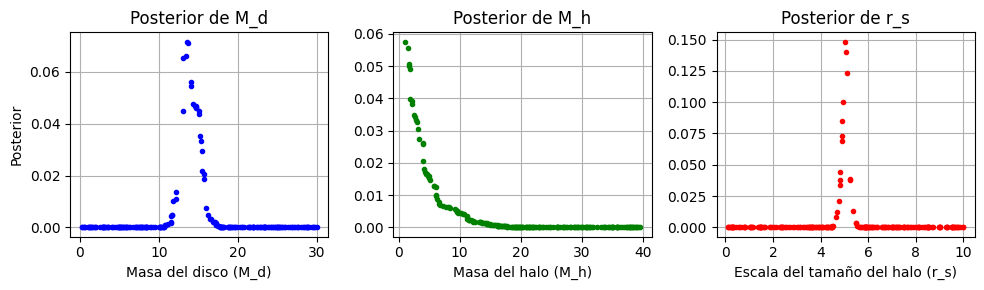

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

# posterior M_d
ax[0].set_title('Posterior de M_d')
ax[0].plot(Mcd_sample, posterior_Md, 'b.')
ax[0].set_xlabel('Masa del disco (M_d)')
ax[0].set_ylabel('Posterior')

# posterior M_h
ax[1].set_title('Posterior de M_h')
ax[1].plot(Mch_sample, posterior_Mh, 'g.')
ax[1].set_xlabel('Masa del halo (M_h)')

# posterior r_s
ax[2].set_title('Posterior de r_s')
ax[2].plot(rs_sample, posterior_rs, 'r.')
ax[2].set_xlabel('Escala del tamaño del halo (r_s)')
ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.tight_layout()
plt.show()

In [ ]:
# Obtener los valores correspondientes de los parámetros
max_M_d = Mcd_sample[np.argmax(posterior_Md)]
max_M_h = Mch_sample[np.argmax(posterior_Mh)]
max_r_s = rs_sample[np.argmax(posterior_rs)]

# Imprimir los valores de máxima probabilidad
print(f"Valor de M_d con máxima probabilidad: {max_M_d}")
print(f"Valor de M_h con máxima probabilidad: {max_M_h}")
print(f"Valor de r_s con máxima probabilidad: {max_r_s}")

Valor de M_d con máxima probabilidad: 13.559005307873743
Valor de M_h con máxima probabilidad: 1.06617916683093
Valor de r_s con máxima probabilidad: 5.023195535471226


Para ser lo mas robusto posible, aunque teniendo en cuenta las limitaciones computacionales de colaboratory, se decidio tomar 10 iteraciones de diferentes likelihoods, cada una tomando distintos samples de tamaño 220 aleatoriamente distribuidos de los parametros, con estos samples se hizo un meshgrid tridimensional que tuviera todas las posibles combinaciones de los valores generados en los samples de cada parametro, con estos se tomó el likelihood, y normalizandolo por su suma total, gracias a que se tomó un prior informativo, se obtuvo la estimacion del posterior asociado a cada sample. Todo esto con el fin de observar una tendencia general y no solo una realizacion estocastica de la distribuion, luego se graficaron todos los posterior superpuestos, junto a su media, asociada tambien a la media de los samples.

In [ ]:
max_M_d_s = []
max_M_h_s = []
max_r_s_s = []
posterior_Md_all = []
posterior_Mh_all = []
posterior_rs_all = []

Md_sampleos = []
Mh_sampleos = []
rs_sampleos = []


n_iter=10

for i in tqdm(range(n_iter)):

  # muestras de parametros
  Mcd_sample = np.random.uniform(0.1, 100-75, sample_size)
  Mch_sample = np.random.uniform(1, 1000-960, sample_size)
  rs_sample = np.random.uniform(0.1, 100-90, sample_size)
  # ordenandolos
  Mcd_sample.sort()
  Mch_sample.sort()
  rs_sample.sort()

  # meshgrid 3D
  Md_3d, Mh_3d, rs_3d = np.meshgrid(Mcd_sample, Mch_sample, rs_sample, indexing='ij')

  # likelihoods
  posterior_values = likelihood(R_real, V_real, sigma_v, Md_3d, Mh_3d, rs_3d)
  posterior_values /= np.sum(posterior_values)  # Normalizando posterior proporcional likelihood (prior uniforme)

  # marginalizacion
  posterior_Md = np.sum(posterior_values, axis=(1, 2))
  posterior_Mh = np.sum(posterior_values, axis=(0, 2))
  posterior_rs = np.sum(posterior_values, axis=(0, 1))


  # Almacenar PDF
  posterior_Md_all.append(posterior_Md)
  posterior_Mh_all.append(posterior_Mh)
  posterior_rs_all.append(posterior_rs)
  # almacenar samples
  Md_sampleos.append(Mcd_sample)
  Mh_sampleos.append(Mch_sample)
  rs_sampleos.append(rs_sample)
  # almacenar maximos
  max_M_d_s.append( Mcd_sample[np.argmax(posterior_Md)] )
  max_M_h_s.append( Mch_sample[np.argmax(posterior_Mh)] )
  max_r_s_s.append( rs_sample[np.argmax(posterior_rs)] )


  # Graficar las PDFs
  ax[0].plot(Mcd_sample, posterior_Md, '.')
  ax[1].plot(Mch_sample, posterior_Mh, '.')
  ax[2].plot(rs_sample,  posterior_rs, '.')


# media de las pdf
posterior_Md_mean = np.mean(np.array(posterior_Md_all), axis=0)
posterior_Mh_mean = np.mean(np.array(posterior_Mh_all), axis=0)
posterior_rs_mean = np.mean(np.array(posterior_rs_all), axis=0)

# media de los sampleos
sample_Md_mean = np.mean(np.array(Md_sampleos), axis=0)
sample_Mh_mean = np.mean(np.array(Mh_sampleos), axis=0)
sample_rs_mean = np.mean(np.array(rs_sampleos), axis=0)



100%|██████████| 10/10 [03:15<00:00, 19.57s/it]


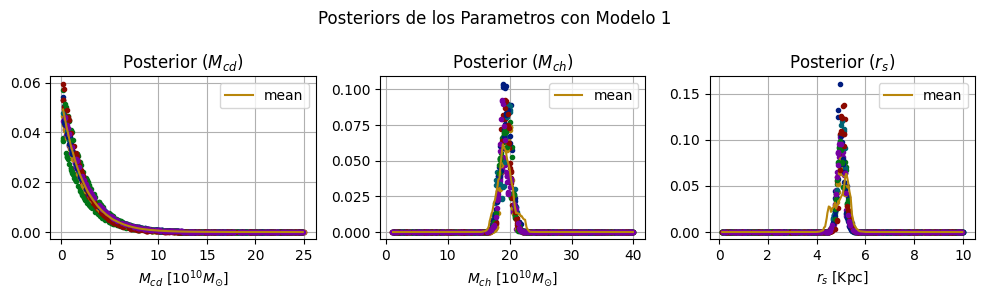

In [ ]:
# Graficar las PDFs promedio
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

fig.suptitle(f'Posteriors de los Parametros con Modelo 1')

# todas las iteraciones
for i, datos_i in enumerate(posterior_Md_all):
    ax[0].plot(Md_sampleos[i], datos_i, '.')

for i, datos_i in enumerate(posterior_Mh_all):
    ax[1].plot(Mh_sampleos[i], datos_i, '.')

for i, datos_i in enumerate(posterior_rs_all):
    ax[2].plot(rs_sampleos[i], datos_i, '.')

# medias
ax[0].set_title("Posterior ($M_{cd}$)")
ax[0].plot(sample_Md_mean, posterior_Md_mean, label='mean')
ax[0].set_xlabel("$M_{cd}$ [$10^{10} M_⊙$]")

ax[1].set_title("Posterior ($M_{ch}$)")
ax[1].plot(sample_Mh_mean, posterior_Mh_mean, label='mean')
ax[1].set_xlabel("$M_{ch}$ [$10^{10} M_⊙$]")

ax[2].set_title("Posterior ($r_s$)")
ax[2].plot(sample_rs_mean, posterior_rs_mean, label='mean')
ax[2].set_xlabel("$r_s$ [Kpc]")

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.show()

Figura 1. Posterior de cada parametro para el Modelo 1. con $n=10$ iteraciones cada una con samples uniformes de tamaño $220$. <br><br>


Para la estimacion de cada parametro se decidio tomar el valor del parametro asociado con el valor maximo de probabilidad MAP aproximado de entre todas las iteraciones, mientras su error se tomó de la estimacion de la desviacion estandar del conjunto de los MAPs aproximados de cada iteracion.

* $M_{cd} = 0.3638 ± 0.07$ [U$_m$]
* $M_{ch} = 20.09 ± 0.46$ [U$_m$]
* $r_s =  5.125 ± 0.054$ [U$_l$]

In [ ]:
max(max_M_d_s), max(max_M_h_s), max(max_r_s_s)

(0.3638184515469759, 20.092422389140744, 5.125115165316686)

In [ ]:
np.std(max_M_d_s), np.std(max_M_h_s), np.std(max_r_s_s)

(0.07444679123714004, 0.4603267192844615, 0.054575481048224496)

## **2. Formalismo Bayesiano**: Modelo 2, velocidad del halo modificado

Se considera una modificacion del modelo de velocidad del halo, que remueve la dependencia lineal del $R$ en el numerador, y reduce el grado de la dependencia del inverso cuadrado de la suma de $R + r_s$. Es decir el modelo del halo seria ahora el siguiente:

$$V_{\text{ch}}^2 (R) = \frac{G M_h}{ ( R + r_s )} $$


Repitiendo todos los pasos del primer caso se obtiene, primero que los intervalos no son exactamente los mismos, el valor maximo de probabilidad de cada parametro se situa en valores distintos.

In [ ]:
def vel_c_old2(R, M_d, M_h, r_s):

  v_cd2 = (G* M_d * R) / ((R**2 + (a+b)**2)**(3/2)) # disco
  v_ch2 = (G* M_h ) / ((R + r_s)) # halo

  return (v_cd2 + v_ch2)**.5


def vel_c2(R, M_d, M_h, r_s):
  R_broad = R_real[np.newaxis, np.newaxis, np.newaxis, :]

  v_cd2 = (G* M_d[..., np.newaxis] * R_broad) / ((R_broad**2 + (a+b)**2)**(3/2)) # disco
  v_ch2 = (G* M_h[..., np.newaxis] ) / ((R_broad + r_s[..., np.newaxis])) # halo

  return (v_cd2 + v_ch2)**.5


def likelihood2(R_real,Vc_real,σ, M_d,M_h,r_s):

  # velocidad modelo
  Vc = vel_c2(R_real[np.newaxis, np.newaxis, np.newaxis, :], M_d, M_h, r_s)
  ϵ = Vc - Vc_real[np.newaxis, np.newaxis, np.newaxis, :] # error

  likeli = np.prod( (1/(2*np.pi*σ**2)**.5) * np.exp(-ϵ**2/(2*σ**2)) , axis=-1)

  return likeli

M_d: 0.36 (+0.01, -0.00)
M_h: 20.09 (+0.00, -0.00)
r_s: 5.13 (+0.00, -0.00)


In [ ]:
sample_size = 220

# muestras de parametros
Mcd_sample = np.random.uniform(0.1, 100, sample_size)
Mch_sample = np.random.uniform(1, 1000, sample_size)
rs_sample = np.random.uniform(0.1, 100, sample_size)

Mcd_sample.sort()
Mch_sample.sort()
rs_sample.sort()

# Crear un meshgrid 3D para las combinaciones de parámetros
Md_3d, Mh_3d, rs_3d = np.meshgrid(Mcd_sample, Mch_sample, rs_sample)

In [ ]:

max_M_d_s2 = []
max_M_h_s2 = []
max_r_s_s2 = []
posterior_Md_all2 = []
posterior_Mh_all2 = []
posterior_rs_all2 = []

Md_sampleos2 = []
Mh_sampleos2 = []
rs_sampleos2 = []

sample_size = 220

n_iter=10

for i in tqdm(range(n_iter)):

  # muestras de parametros
  Mcd_sample = np.random.uniform(0.1, 100, sample_size)
  Mch_sample = np.random.uniform(1, 1000, sample_size)
  rs_sample = np.random.uniform(0.1, 100, sample_size)
  # ordenandolos
  Mcd_sample.sort()
  Mch_sample.sort()
  rs_sample.sort()

  # meshgrid 3D
  Md_3d, Mh_3d, rs_3d = np.meshgrid(Mcd_sample, Mch_sample, rs_sample, indexing='ij')

  # likelihoods
  posterior_values2 = likelihood2(R_real, V_real, sigma_v, Md_3d, Mh_3d, rs_3d)
  posterior_values2 /= np.sum(posterior_values2)  # Normalizando posterior proporcional likelihood (prior uniforme)

  # marginalizacion
  posterior_Md2 = np.sum(posterior_values2, axis=(1, 2))
  posterior_Mh2 = np.sum(posterior_values2, axis=(0, 2))
  posterior_rs2 = np.sum(posterior_values2, axis=(0, 1))


  # Almacenar PDF
  posterior_Md_all2.append(posterior_Md2)
  posterior_Mh_all2.append(posterior_Mh2)
  posterior_rs_all2.append(posterior_rs2)
  # almacenar samples
  Md_sampleos2.append(Mcd_sample)
  Mh_sampleos2.append(Mch_sample)
  rs_sampleos2.append(rs_sample)
  # almacenar maximos
  max_M_d_s2.append( Mcd_sample[np.argmax(posterior_Md2)] )
  max_M_h_s2.append( Mch_sample[np.argmax(posterior_Mh2)] )
  max_r_s_s2.append( rs_sample[np.argmax(posterior_rs2)] )



# media de las pdf
posterior_Md_mean2 = np.mean(np.array(posterior_Md_all2), axis=0)
posterior_Mh_mean2 = np.mean(np.array(posterior_Mh_all2), axis=0)
posterior_rs_mean2 = np.mean(np.array(posterior_rs_all2), axis=0)

# media de los sampleos
sample_Md_mean2 = np.mean(np.array(Md_sampleos2), axis=0)
sample_Mh_mean2 = np.mean(np.array(Mh_sampleos2), axis=0)
sample_rs_mean2 = np.mean(np.array(rs_sampleos2), axis=0)


100%|██████████| 10/10 [03:17<00:00, 19.76s/it]


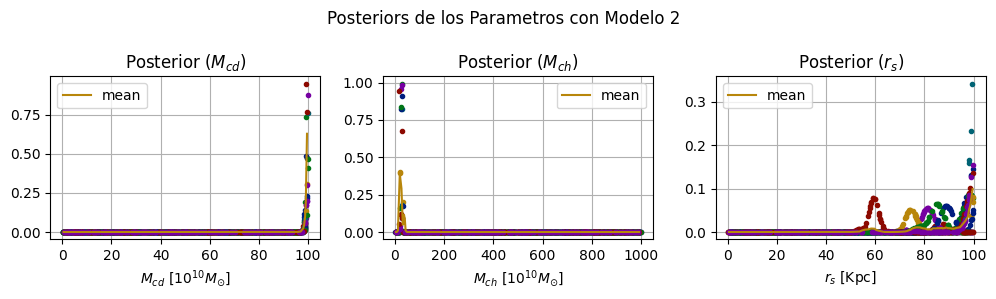

In [ ]:
# Graficar las PDFs promedio
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

fig.suptitle(f'Posteriors de los Parametros con Modelo 2')

# todas las iteraciones
for i, datos_i in enumerate(posterior_Md_all2):
    ax[0].plot(Md_sampleos2[i], datos_i, '.')

for i, datos_i in enumerate(posterior_Mh_all2):
    ax[1].plot(Mh_sampleos2[i], datos_i, '.')

for i, datos_i in enumerate(posterior_rs_all2):
    ax[2].plot(rs_sampleos2[i], datos_i, '.')

# medias
ax[0].set_title("Posterior ($M_{cd}$)")
ax[0].plot(sample_Md_mean2, posterior_Md_mean2, label='mean')
ax[0].set_xlabel("$M_{cd}$ [$10^{10} M_⊙$]")

ax[1].set_title("Posterior ($M_{ch}$)")
ax[1].plot(sample_Mh_mean2, posterior_Mh_mean2, label='mean')
ax[1].set_xlabel("$M_{ch}$ [$10^{10} M_⊙$]")

ax[2].set_title("Posterior ($r_s$)")
ax[2].plot(sample_rs_mean2, posterior_rs_mean2, label='mean')
ax[2].set_xlabel("$r_s$ [Kpc]")

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.show()

Figura 2. Posterior de cada parametro para el Modelo 2. con $n=10$ iteraciones cada una con samples uniformes de tamaño $220$. <br><br>

Donde la estimacion de los parametros se decidió con el mismo criterio y fue:

* $M_{cd} = 99.99 ± 0.32 $ [U$_m$]
* $M_{ch} = 30.28 ± 4.02$ [U$_m$]
* $r_s = 99.98 ± 12.5$ [U$_l$]

In [ ]:
max(max_M_d_s2), max(max_M_h_s2), max(max_r_s_s2)

(99.99588368868471, 30.280844837244867, 99.98271402258707)

In [ ]:
np.std(max_M_d_s2), np.std(max_M_h_s2), np.std(max_r_s_s2)

(0.32397805440033306, 4.026549021532513, 12.568543927621022)

## **3. Comparacion de modelos por $χ^2$ respecto a los datos**

### **Prueba de hipotesis**:

¿Cual de los dos modelos describe mejor los datos?


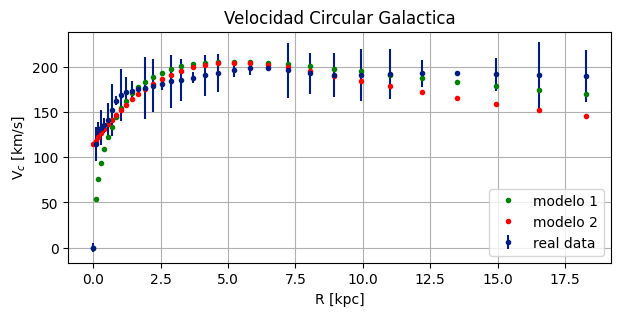

In [ ]:
vel_c_bayes = vel_c_old(R_real, max(max_M_d_s), max(max_M_h_s), max(max_r_s_s))
vel_c_bayes2 = vel_c_old2(R_real, max(max_M_d_s2), max(max_M_h_s2), max(max_r_s_s2))

fig = plt.figure(figsize=(7,3))
plt.title('Velocidad Circular Galactica')
plt.errorbar(R_real, V_real, yerr=sigma_v ,fmt='.', label='real data')
plt.plot(R_real, vel_c_bayes, 'g.',label='modelo 1')
plt.plot(R_real, vel_c_bayes2, 'r.',label='modelo 2')
plt.ylabel('V$_c$ [km/s]')
plt.xlabel('R [kpc]')
plt.legend()
plt.grid()

Figura 3. Comparacion de los Modelos y los Datos observados. <br><br>


Este estadístico se calcula como la suma de los cuadrados de las diferencias entre los valores observados y los valores predichos, normalizados por los valores predichos por el modelo.


$$  \chi^2 = \sum_i \frac{(V_{\text{datos}} - V_{\text{modelo}})^2}{V_{\text{modelo}}}
$$

Donde  $V_{\text{real}} $ son los datos observados, $ V_{\text{modelo}} $ son los valores predichos por el modelo.





Este test te permitirá evaluar de manera cuantitativa cuál de los dos modelos es más adecuado para describir los datos reales.

con un CL del $90$%, y los grados de libertar $ν=n_{datos}-n_{params}-1 = 29$

Evaluando la formula se obtiene
* $χ^2$ del modelo 1 = 153.54
* $χ^2$ del modelo 2 = 50.08 <br>

Este valor representa la distancia cuadratica normalizada de los modelos a los datos tomados, de modo que entre ambos modelos, el que mejor se ajusta a los datos es el segundo, pues tiene menor discrepancia.

A pesar de que como se observa en la figura 3, los dos modelos parecen tener una buena tendencia de ajuste a primera vista. por otro lado, el valor critico del estimador es de aproximadamente $39.087$, lo que rechazaria ambos modelos, pero este estimador no es exactamente el mismo, los valores de $χ^2$ de ambos modelos representa mas que todo la discrepancia entre los modelos y los datos reales, mientras el valor critico esta asociado y requiere calculos mejor elaborados como recurriendo a la estimacion de la PDF de cada modelo.

In [ ]:
grados_libertad = len(V_real) - 3-1
grados_libertad

29

In [ ]:
# Cálculo de Chi Cuadrado para el modelo 1
chi2_modelo1 = np.sum((V_real[1:] - vel_c_bayes[1:]) **2 / vel_c_bayes[1:])

# Cálculo de Chi Cuadrado para el modelo 2
chi2_modelo2 = np.sum((V_real[1:] - vel_c_bayes2[1:]) ** 2 / vel_c_bayes2[1:])

# Imprimir los resultados
print(f"Chi cuadrado del modelo 1: {chi2_modelo1}")
print(f"Chi cuadrado del modelo 2: {chi2_modelo2}")

# Comparar cuál modelo se ajusta mejor
if chi2_modelo1 < chi2_modelo2:
    print("El modelo 1 se ajusta mejor a los datos.")
else:
    print("El modelo 2 se ajusta mejor a los datos.")

Chi cuadrado del modelo 1: 153.54327442116985
Chi cuadrado del modelo 2: 50.0876972435036
El modelo 2 se ajusta mejor a los datos.


In [ ]:
from scipy.stats import chi2

alpha = 0.10  # Nivel de significancia
chi2_critico = chi2.ppf(1 - alpha, grados_libertad)
chi2_critico

39.08746977069396